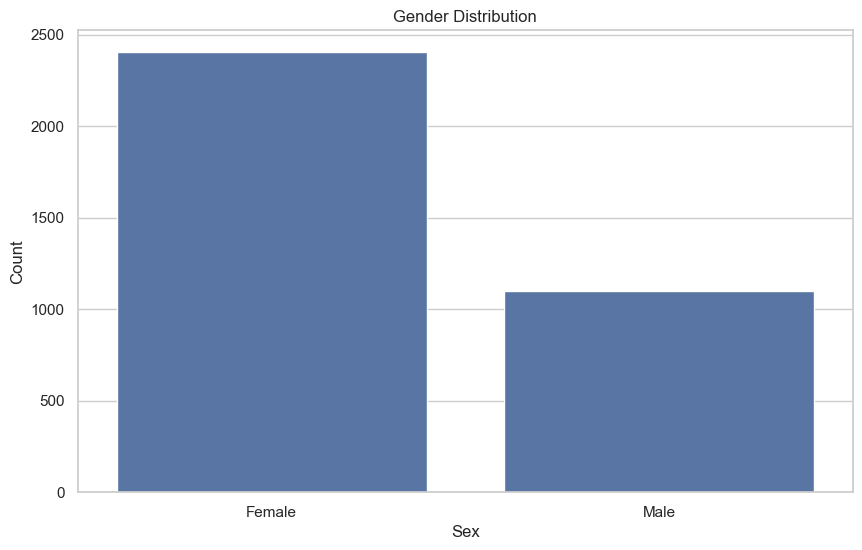

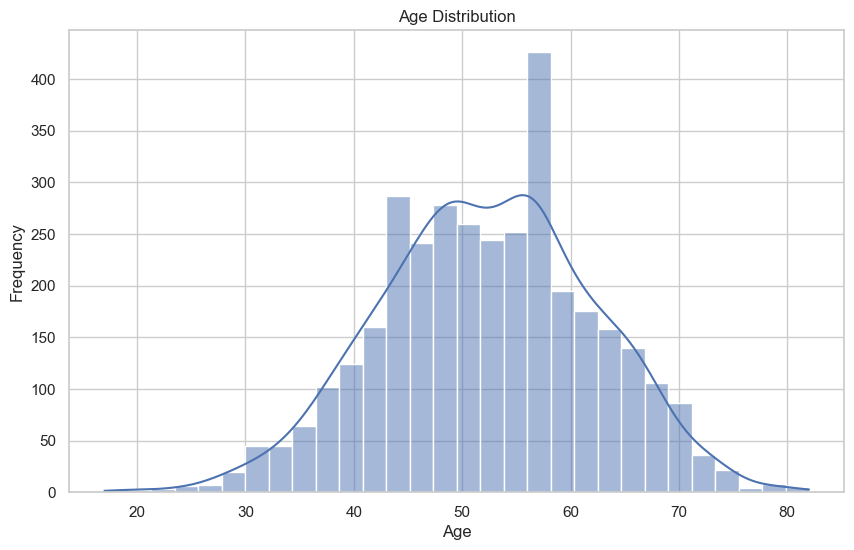

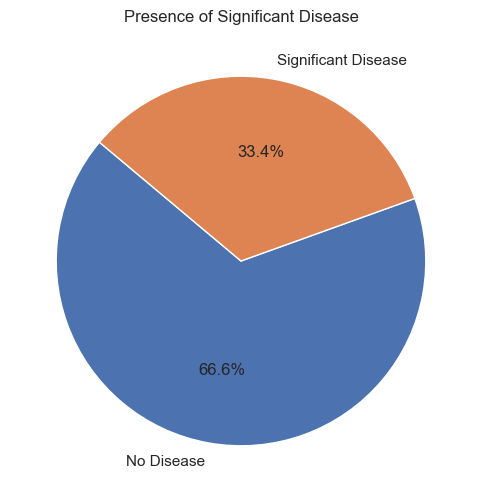

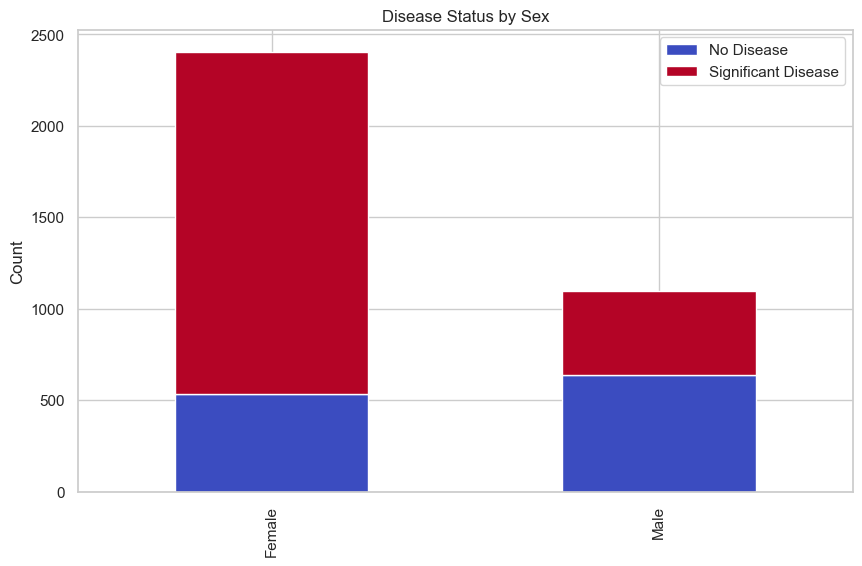

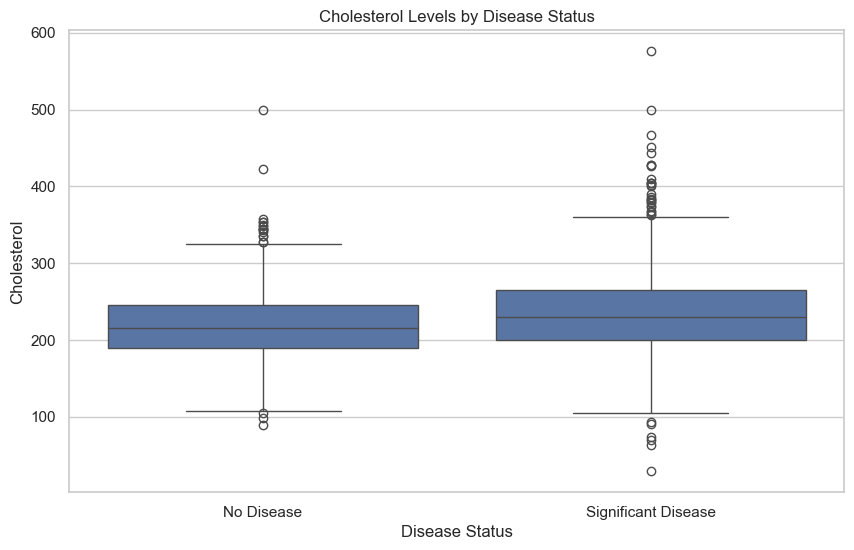

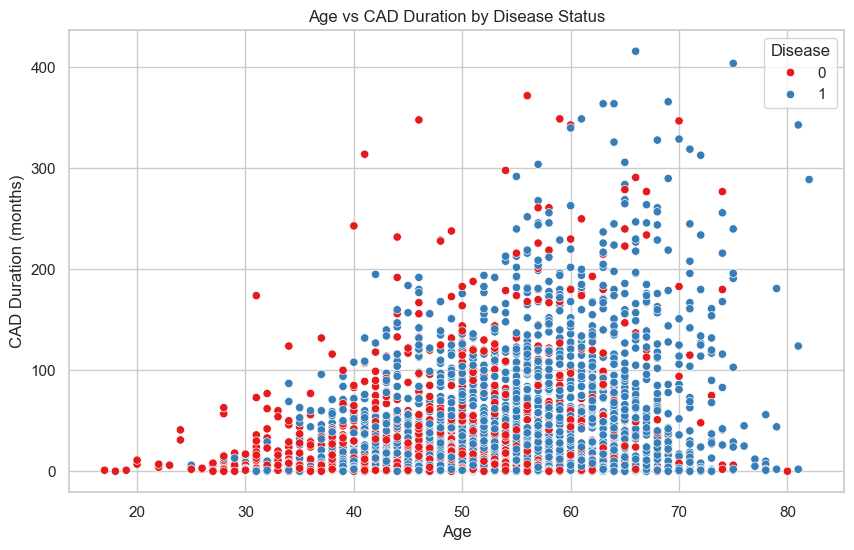

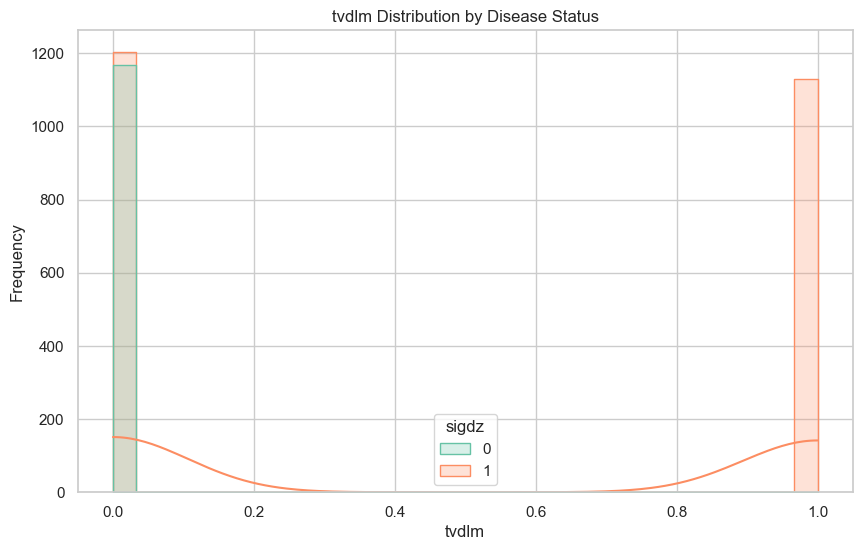

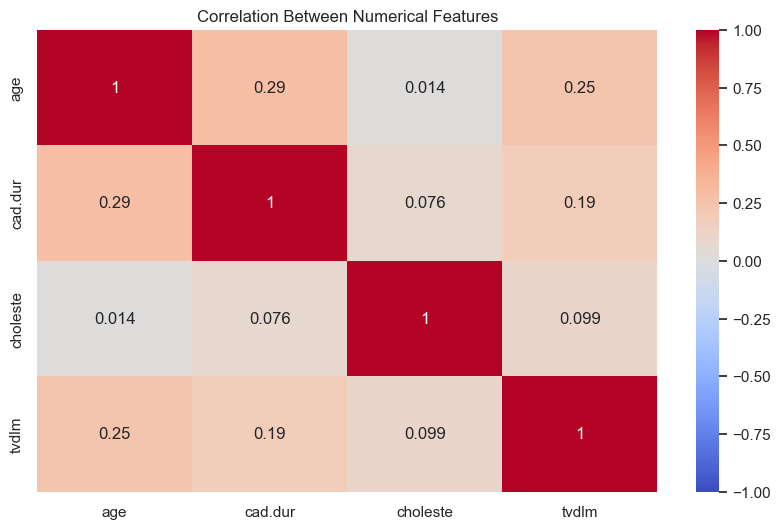

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Cardiac_Catheretization_Diagnosis.csv")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 1. Gender Distribution
sns.countplot(x='sex', data=df)
plt.xticks([0, 1], ['Female', 'Male'])
plt.title('Gender Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

# 2. Age Distribution
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# 3. Pie Chart of Disease Status
df_sigdz = df['sigdz'].value_counts()
plt.pie(df_sigdz, labels=['No Disease', 'Significant Disease'], autopct='%1.1f%%', startangle=140)
plt.title('Presence of Significant Disease')
plt.show()

# 4. Disease Status by Sex
sigdz_by_sex = pd.crosstab(df['sex'], df['sigdz'])
sigdz_by_sex.index = ['Female', 'Male']
sigdz_by_sex.columns = ['No Disease', 'Significant Disease']
sigdz_by_sex.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title('Disease Status by Sex')
plt.ylabel('Count')
plt.show()

# 5. Cholesterol by Disease Status
sns.boxplot(x='sigdz', y='choleste', data=df)
plt.xticks([0, 1], ['No Disease', 'Significant Disease'])
plt.title('Cholesterol Levels by Disease Status')
plt.xlabel('Disease Status')
plt.ylabel('Cholesterol')
plt.show()

# 6. Age vs CAD Duration by Disease
sns.scatterplot(data=df, x='age', y='cad.dur', hue='sigdz', palette='Set1')
plt.title('Age vs CAD Duration by Disease Status')
plt.xlabel('Age')
plt.ylabel('CAD Duration (months)')
plt.legend(title='Disease')
plt.show()

# 7. tvdlm Distribution by Disease
sns.histplot(data=df, x='tvdlm', hue='sigdz', bins=30, kde=True, element='step', palette='Set2')
plt.title('tvdlm Distribution by Disease Status')
plt.xlabel('tvdlm')
plt.ylabel('Frequency')
plt.show()

# 8. Correlation Heatmap
corr = df[['age', 'cad.dur', 'choleste', 'tvdlm']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Between Numerical Features')
plt.show()


/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_9806/1098661070.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 0], data=df, x="sex_label", palette=palette)
/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_9806/1098661070.py:22: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.countplot(ax=axes[0, 0], data=df, x="sex_label", palette=palette)
/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_9806/1098661070.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2, 0], data=df, x="sigdz_label", y="choleste", palette=palette[:2])


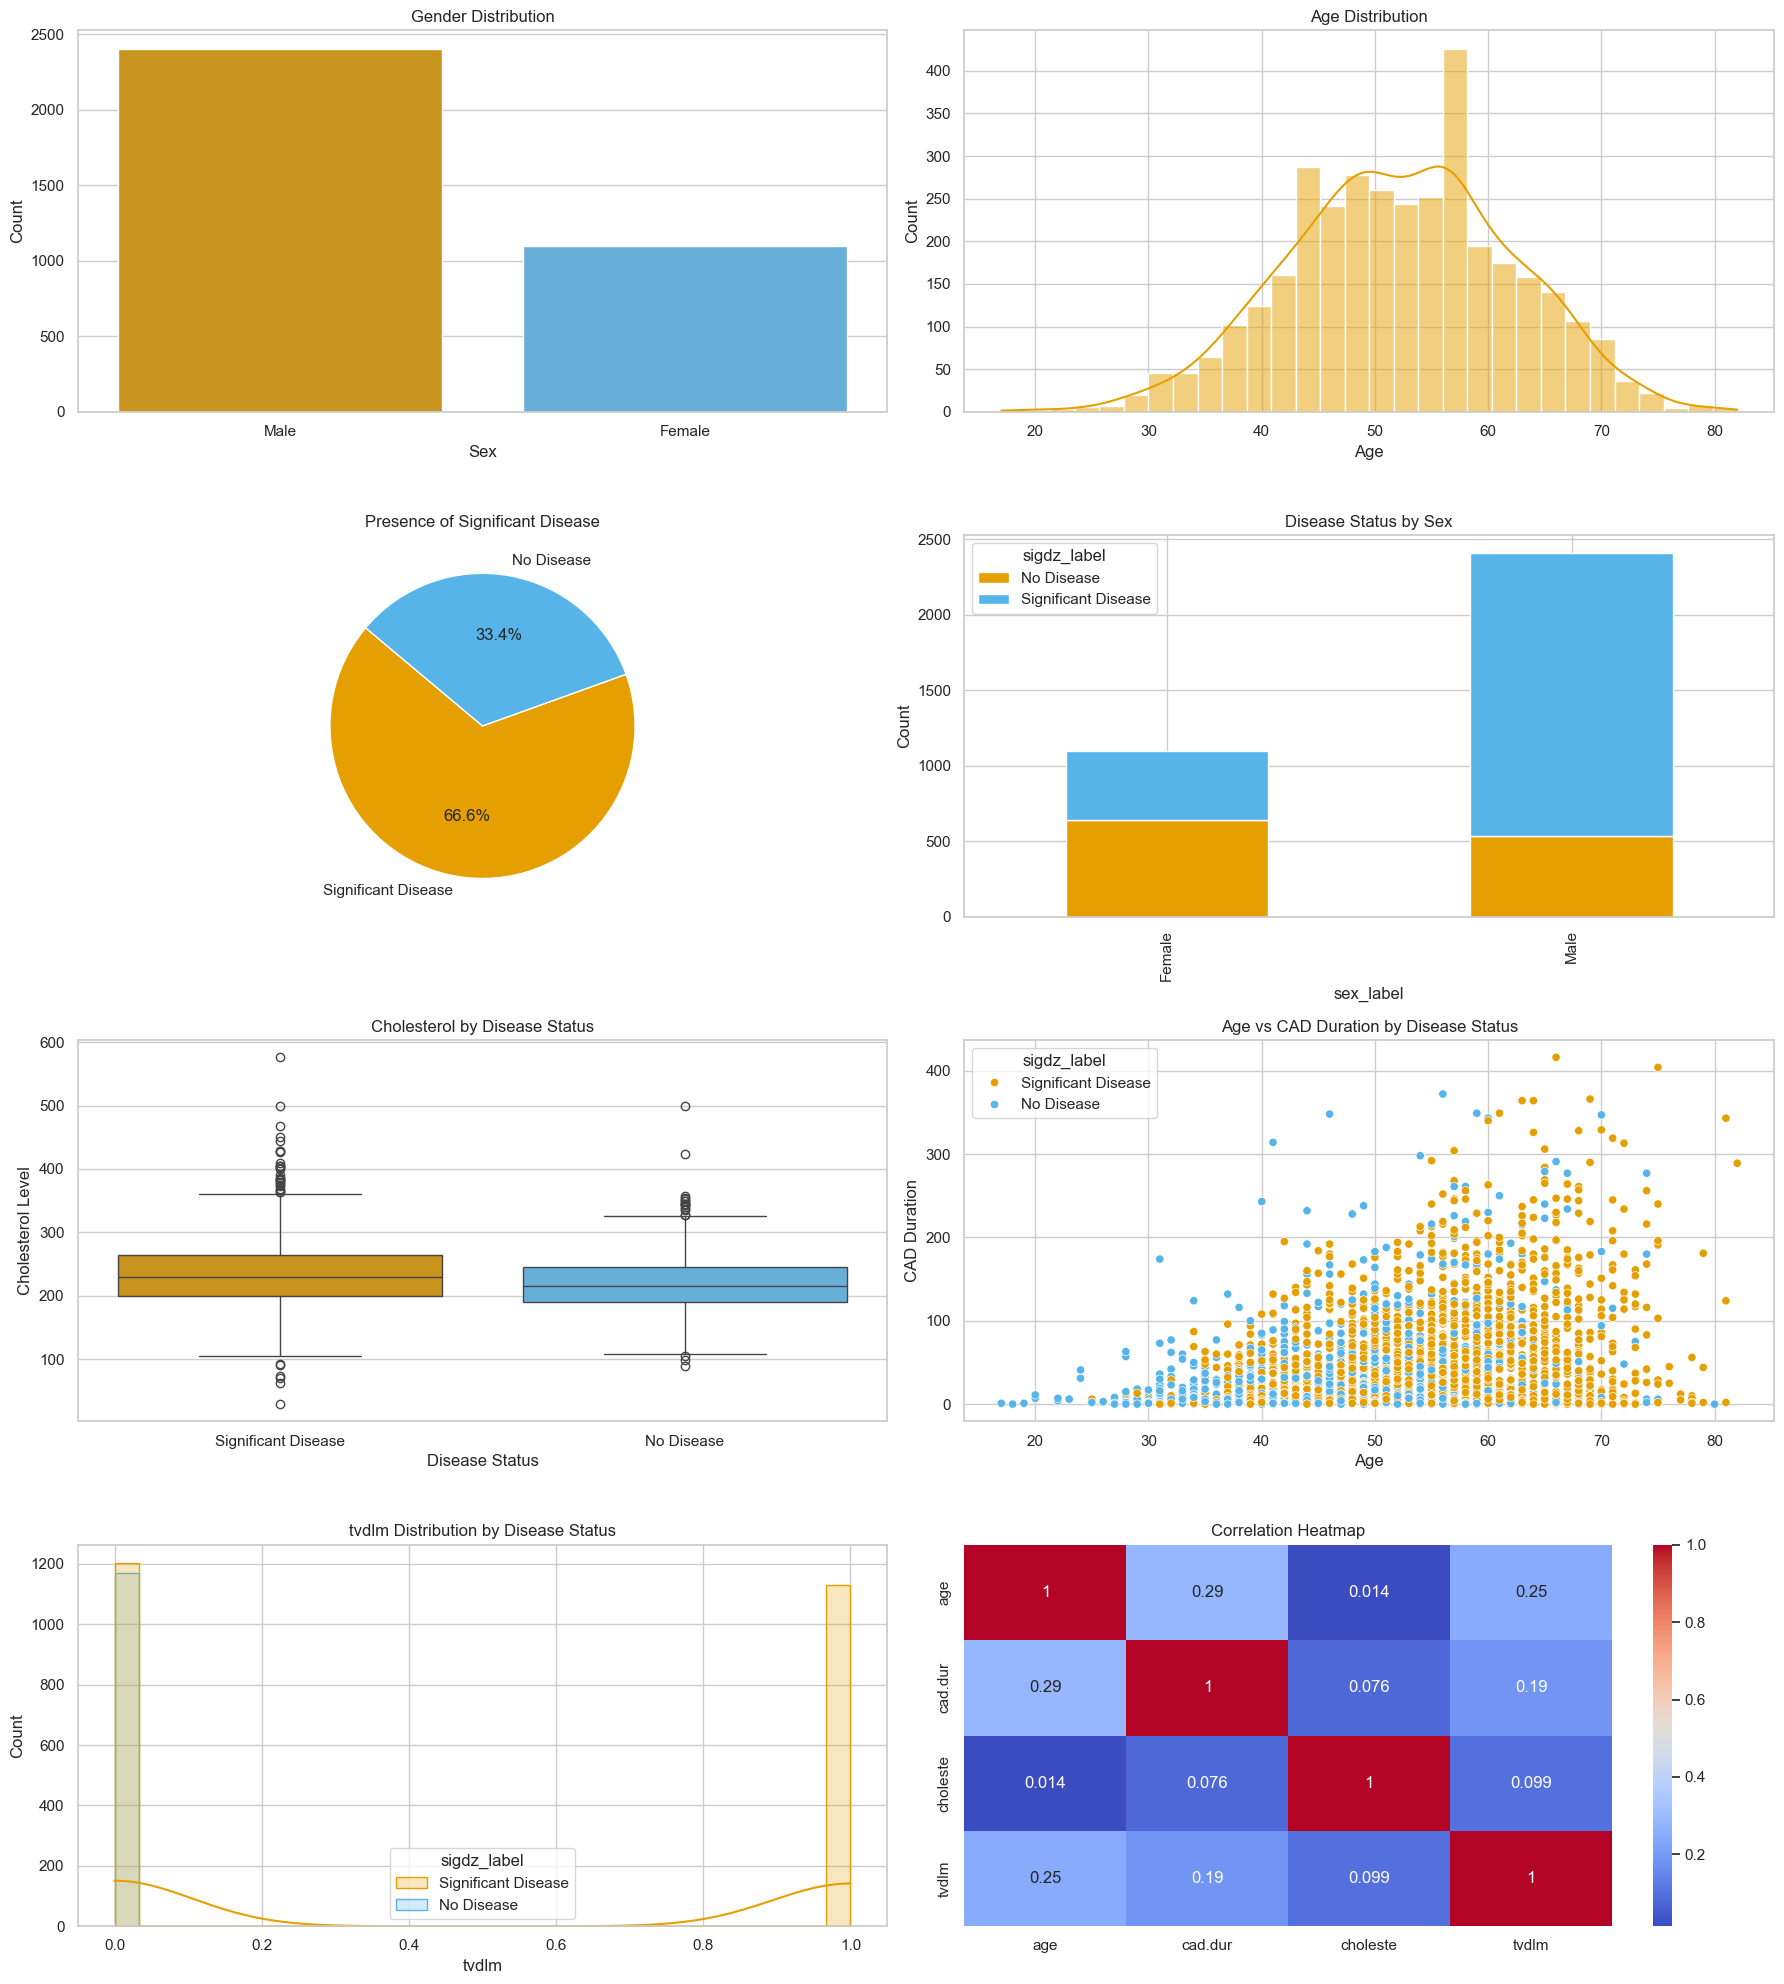

In [5]:
# initial responses in a clean format - prompt #1: 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("Cardiac_Catheretization_Diagnosis.csv")

# Add human-readable labels
df["sex_label"] = df["sex"].map({0: "Male", 1: "Female"})
df["sigdz_label"] = df["sigdz"].map({0: "No Disease", 1: "Significant Disease"})

# Colorblind-friendly palette
palette = ["#E69F00", "#56B4E9", "#009E73"]

# Set up the subplot grid
sns.set(style="whitegrid")
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
plt.subplots_adjust(hspace=0.5)

# 1. Gender Distribution
sns.countplot(ax=axes[0, 0], data=df, x="sex_label", palette=palette)
axes[0, 0].set_title("Gender Distribution")
axes[0, 0].set_xlabel("Sex")
axes[0, 0].set_ylabel("Count")

# 2. Age Distribution
sns.histplot(ax=axes[0, 1], data=df, x="age", kde=True, bins=30, color=palette[0])
axes[0, 1].set_title("Age Distribution")
axes[0, 1].set_xlabel("Age")

# 3. Disease Prevalence Pie
df_sigdz = df["sigdz_label"].value_counts()
axes[1, 0].pie(df_sigdz, labels=df_sigdz.index, autopct="%1.1f%%", colors=palette[:2], startangle=140)
axes[1, 0].set_title("Presence of Significant Disease")

# 4. Disease Status by Sex
sigdz_by_sex = pd.crosstab(df["sex_label"], df["sigdz_label"])
sigdz_by_sex.plot(kind="bar", stacked=True, ax=axes[1, 1], color=palette[:2])
axes[1, 1].set_title("Disease Status by Sex")
axes[1, 1].set_ylabel("Count")

# 5. Cholesterol by Disease
sns.boxplot(ax=axes[2, 0], data=df, x="sigdz_label", y="choleste", palette=palette[:2])
axes[2, 0].set_title("Cholesterol by Disease Status")
axes[2, 0].set_xlabel("Disease Status")
axes[2, 0].set_ylabel("Cholesterol Level")

# 6. Age vs CAD Duration by Disease
sns.scatterplot(ax=axes[2, 1], data=df, x="age", y="cad.dur", hue="sigdz_label", palette=palette[:2])
axes[2, 1].set_title("Age vs CAD Duration by Disease Status")
axes[2, 1].set_xlabel("Age")
axes[2, 1].set_ylabel("CAD Duration")

# 7. tvdlm Distribution by Disease
sns.histplot(ax=axes[3, 0], data=df, x="tvdlm", hue="sigdz_label", bins=30, kde=True, palette=palette[:2], element='step')
axes[3, 0].set_title("tvdlm Distribution by Disease Status")
axes[3, 0].set_xlabel("tvdlm")

# 8. Correlation Heatmap
corr = df[["age", "cad.dur", "choleste", "tvdlm"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[3, 1])
axes[3, 1].set_title("Correlation Heatmap")

# Final layout fix
plt.tight_layout()
plt.show()


/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_9806/392305845.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 0], data=df, x="sex_label", palette=cb_palette)
/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_9806/392305845.py:31: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.countplot(ax=axes[0, 0], data=df, x="sex_label", palette=cb_palette)
/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_9806/392305845.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2, 0], data=df, x="sigdz_label", y="choleste", palette=cb_palette[:2])


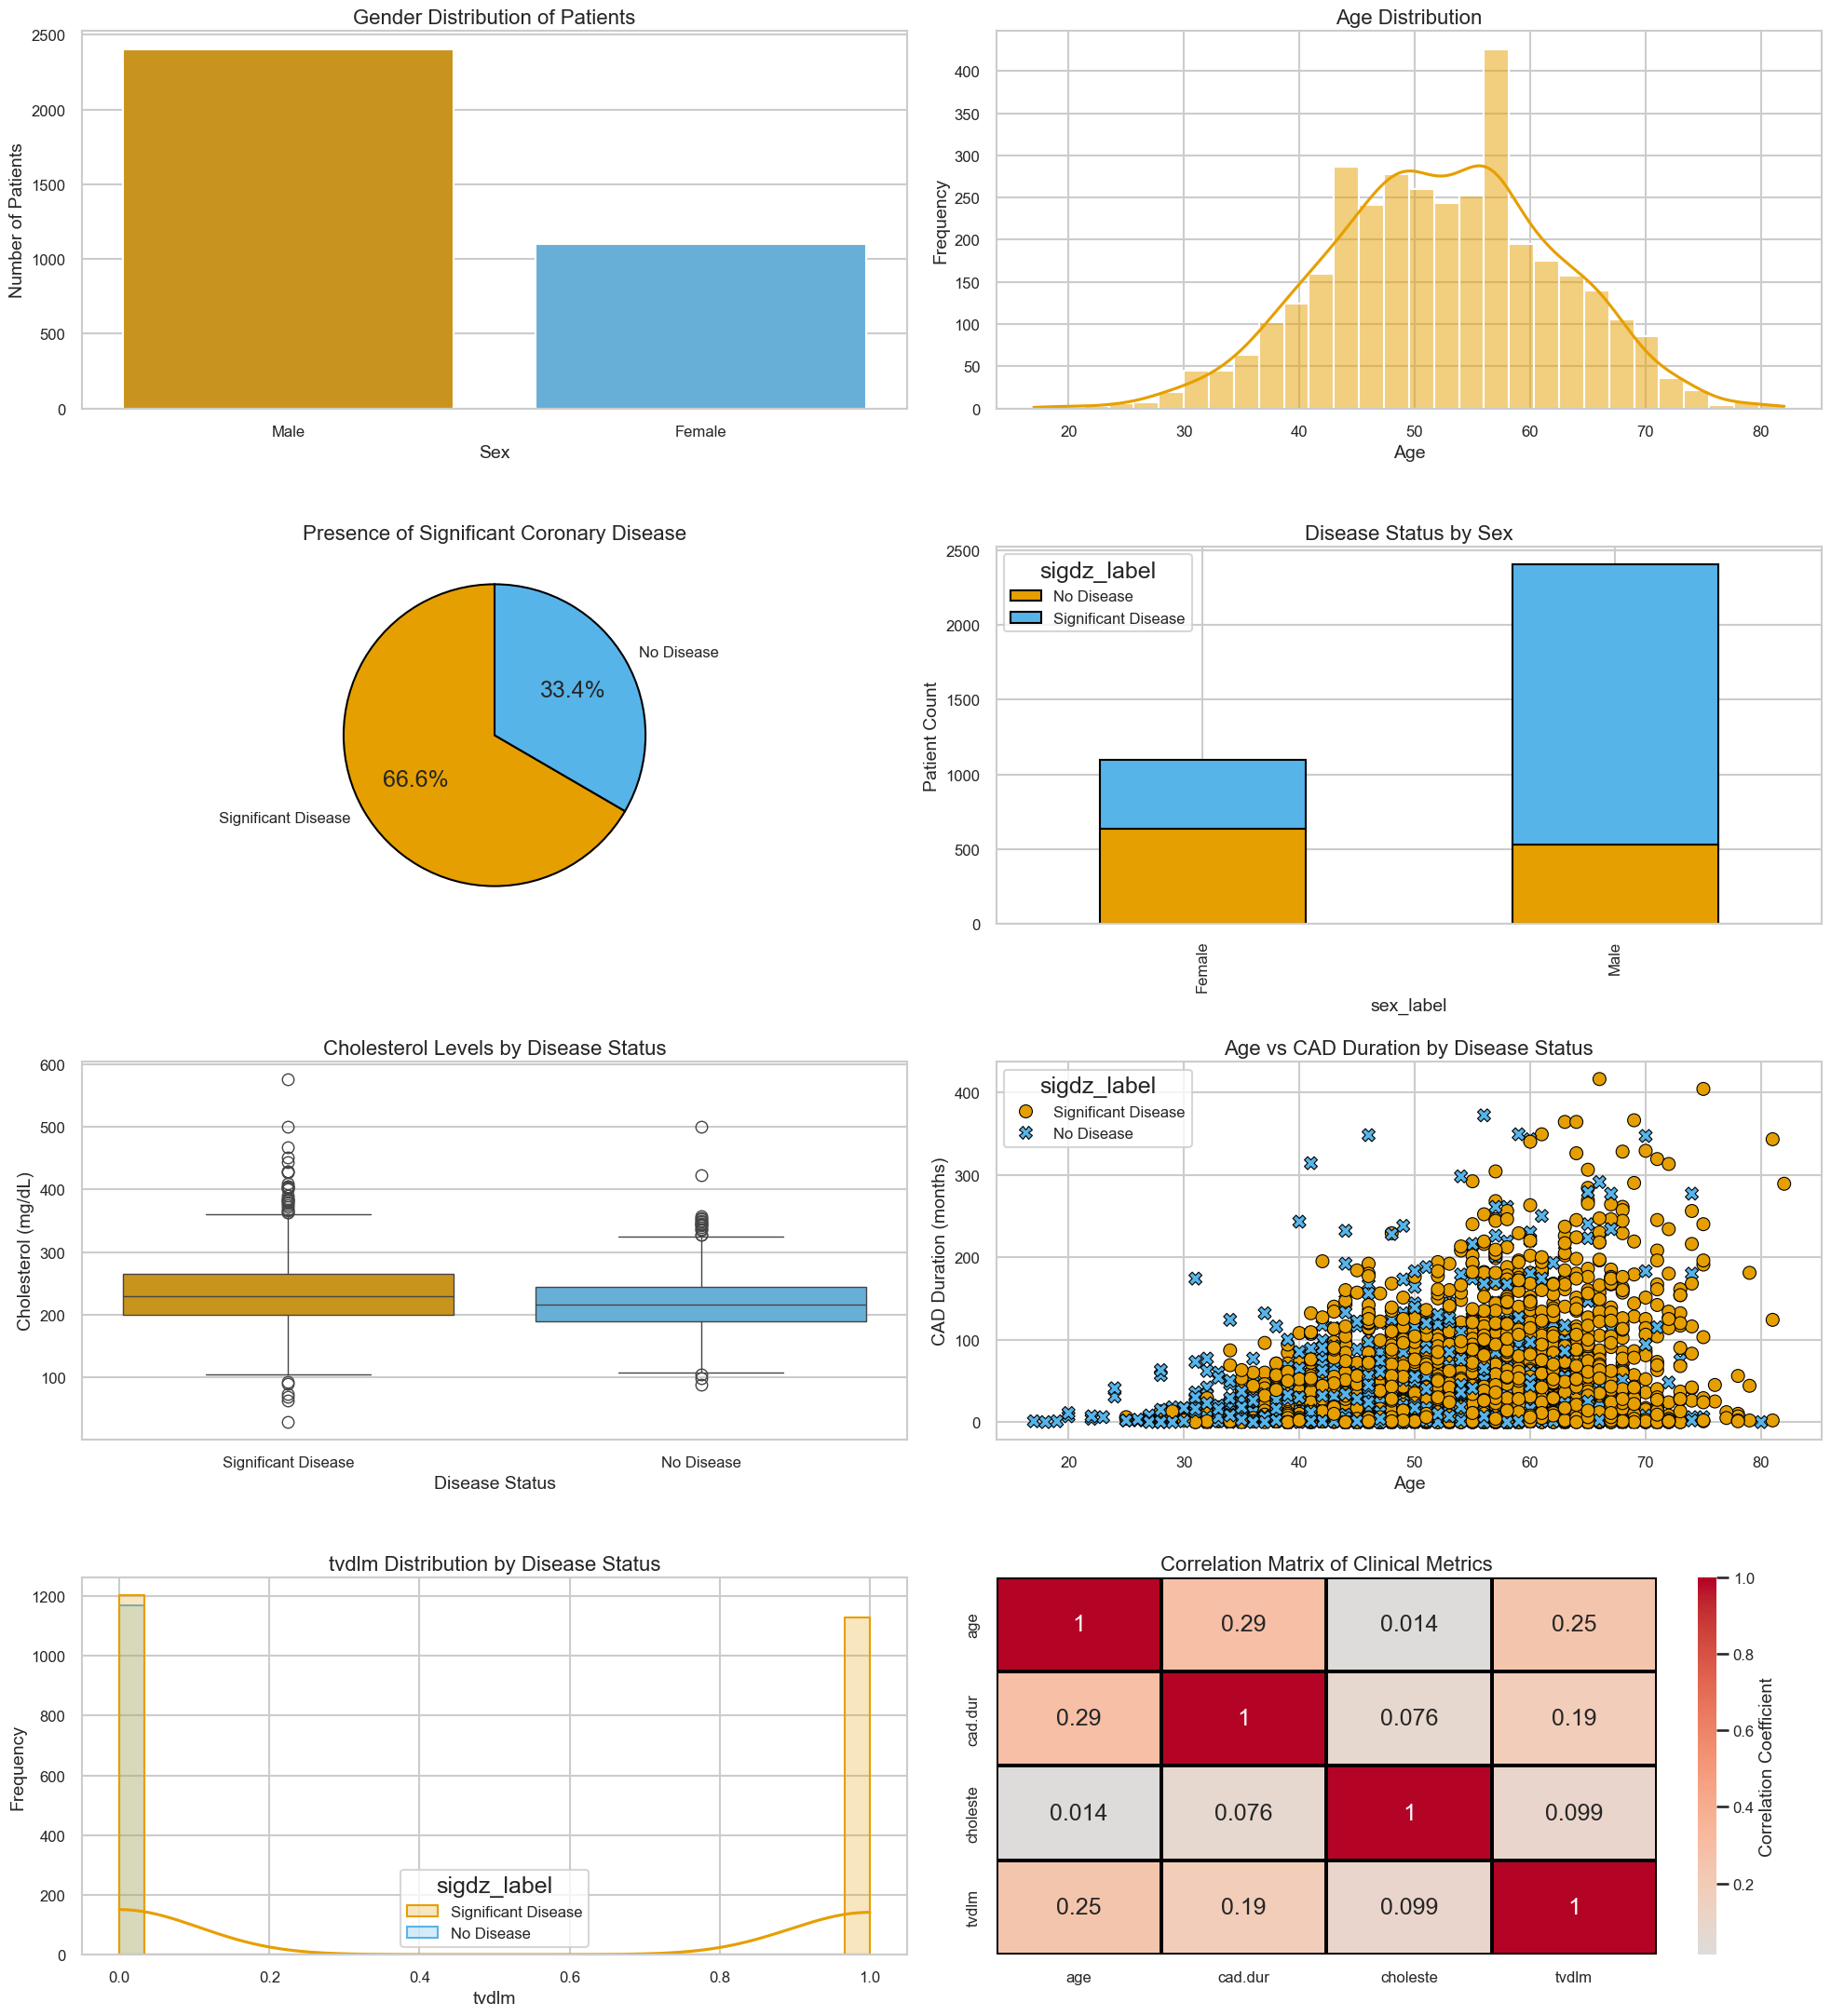

In [7]:
# improved response for better accessibility - prompt #2:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("Cardiac_Catheretization_Diagnosis.csv")
df["sex_label"] = df["sex"].map({0: "Male", 1: "Female"})
df["sigdz_label"] = df["sigdz"].map({0: "No Disease", 1: "Significant Disease"})

# Define colorblind-friendly palette (Okabe-Ito)
cb_palette = ["#E69F00", "#56B4E9", "#009E73", "#D55E00"]

# Set general visual style
sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.5
})

# Create the figure and axes grid
fig, axes = plt.subplots(4, 2, figsize=(20, 22))
plt.subplots_adjust(hspace=0.5)

# 1. Gender Distribution
sns.countplot(ax=axes[0, 0], data=df, x="sex_label", palette=cb_palette)
axes[0, 0].set_title("Gender Distribution of Patients")
axes[0, 0].set_xlabel("Sex")
axes[0, 0].set_ylabel("Number of Patients")

# 2. Age Distribution
sns.histplot(ax=axes[0, 1], data=df, x="age", bins=30, kde=True, color=cb_palette[0])
axes[0, 1].set_title("Age Distribution")
axes[0, 1].set_xlabel("Age")
axes[0, 1].set_ylabel("Frequency")

# 3. Disease Prevalence Pie (add patterns)
df_sigdz = df["sigdz_label"].value_counts()
axes[1, 0].pie(
    df_sigdz,
    labels=df_sigdz.index,
    autopct="%1.1f%%",
    colors=cb_palette[:2],
    startangle=90,
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'black'}
)
axes[1, 0].set_title("Presence of Significant Coronary Disease")

# 4. Disease by Sex (Stacked Bar)
sigdz_by_sex = pd.crosstab(df["sex_label"], df["sigdz_label"])
sigdz_by_sex.plot(
    kind="bar",
    stacked=True,
    ax=axes[1, 1],
    color=cb_palette[:2],
    edgecolor="black"
)
axes[1, 1].set_title("Disease Status by Sex")
axes[1, 1].set_ylabel("Patient Count")

# 5. Cholesterol Levels by Disease
sns.boxplot(ax=axes[2, 0], data=df, x="sigdz_label", y="choleste", palette=cb_palette[:2])
axes[2, 0].set_title("Cholesterol Levels by Disease Status")
axes[2, 0].set_xlabel("Disease Status")
axes[2, 0].set_ylabel("Cholesterol (mg/dL)")

# 6. Age vs CAD Duration by Disease
sns.scatterplot(
    ax=axes[2, 1],
    data=df,
    x="age",
    y="cad.dur",
    hue="sigdz_label",
    palette=cb_palette[:2],
    style="sigdz_label",
    markers=True,
    edgecolor="black",
    s=100
)
axes[2, 1].set_title("Age vs CAD Duration by Disease Status")
axes[2, 1].set_xlabel("Age")
axes[2, 1].set_ylabel("CAD Duration (months)")

# 7. tvdlm Distribution
sns.histplot(
    ax=axes[3, 0],
    data=df,
    x="tvdlm",
    hue="sigdz_label",
    palette=cb_palette[:2],
    bins=30,
    kde=True,
    element="step"
)
axes[3, 0].set_title("tvdlm Distribution by Disease Status")
axes[3, 0].set_xlabel("tvdlm")
axes[3, 0].set_ylabel("Frequency")

# 8. Correlation Heatmap
numeric_cols = ["age", "cad.dur", "choleste", "tvdlm"]
corr = df[numeric_cols].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=1.5,
    linecolor='black',
    ax=axes[3, 1],
    cbar_kws={'label': 'Correlation Coefficient'}
)
axes[3, 1].set_title("Correlation Matrix of Clinical Metrics")

# Save and display
plt.tight_layout()
plt.savefig("accessible_disease_dashboard.png", dpi=300)
plt.show()
